In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from common import model, tok, encode, LANGS, FFNHooks
from compute import load_flores
from ablate import lape_select
import matplotlib.pyplot as plt

c:\Users\sarav\projects\mbert-language-neurons\.pixi\envs\default\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 202/202 [00:00<00:00, 2027.72it/s]
[transformers] BertForMaskedLM LOAD REPORT from: google-bert/bert-base-multilingual-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
P = np.stack([np.load(f"../cache/P_{c}.npy") for c in LANGS])

with np.errstate(divide="ignore", invalid="ignore"):
    q = P / P.sum(0)
    lape = -np.nansum(q * np.log(q), axis=0)
lape[P.sum(0) == 0] = np.inf
kept = np.zeros(lape.shape, bool)
kept.flat[np.argsort(lape, axis=None)[:int(0.01 * lape.size)]] = True
tau = np.percentile(P, 95)

print("kept:", kept.sum(), "tau:", tau)
print("same as saved sel:", ((kept & (P > tau)) == np.load("../cache/sel.npy")).all())

kept: 368 tau: 0.4403178
same as saved sel: True


In [3]:
sel = np.load(r"..\cache\sel.npy")            # (6, 12, 3072)

per_lang = sel.sum(axis=(1, 2))           # neurons per language
n_langs  = sel.sum(axis=0)                # (12, 3072): languages per neuron
several  = (n_langs >= 2).sum()

for code, n in zip(LANGS, per_lang):
    print(code, n)
print("several languages:", several)
print("distinct assigned neurons:", (n_langs >= 1).sum())

eng_Latn 9
fra_Latn 14
deu_Latn 13
rus_Cyrl 9
cmn_Hans 8
yor_Latn 45
several languages: 0
distinct assigned neurons: 98


In [4]:
for c in LANGS:
    s = load_flores(c, "dev")["text"].tolist()[:200]
    print(c, np.mean([len(tok.tokenize(x)) for x in s]))

eng_Latn 28.625
fra_Latn 37.955
deu_Latn 35.435
rus_Cyrl 42.58
cmn_Hans 42.535
yor_Latn 58.61


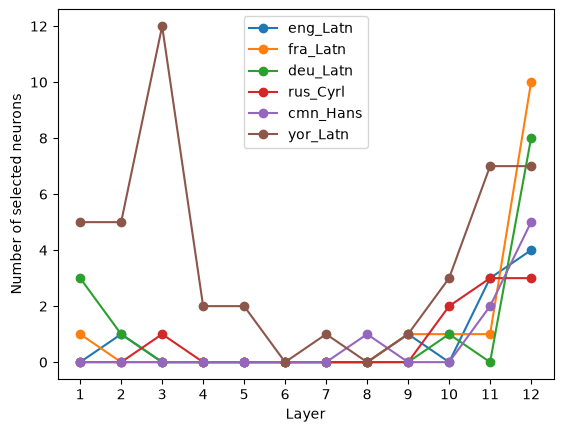

In [5]:
sel = np.load("../cache/sel.npy")       # (6, 12, 3072)
per_layer = sel.sum(axis=2)          # (6, 12): neurons per language and layer

for k, code in enumerate(LANGS):
    plt.plot(range(1, 13), per_layer[k], marker="o", label=code)
plt.xlabel("Layer")
plt.ylabel("Number of selected neurons")
plt.xticks(range(1, 13))
plt.legend()
plt.savefig("../results/neurons_per_layer.pdf", bbox_inches="tight")
plt.show()

In [6]:
langs_no_de = [c for c in LANGS if c != "deu_Latn"]
P = np.stack([np.load(f"../cache/P_{c}.npy") for c in LANGS])
P_no_de = np.stack([np.load(f"../cache/P_{c}.npy") for c in langs_no_de])

sel, _, tau = lape_select(P)
sel_no_de, _, tau_no_de = lape_select(P_no_de)

A = sel[LANGS.index("fra_Latn")]                 # French with German
B = sel_no_de[langs_no_de.index("fra_Latn")]     # French without German
jaccard = (A & B).sum() / (A | B).sum()

print("French with German:", A.sum(), "| without:", B.sum(), "| common:", (A & B).sum())
print("tau:", tau, "->", tau_no_de)
print("Jaccard:", jaccard)

French with German: 14 | without: 15 | common: 12
tau: 0.4403178 -> 0.44122857
Jaccard: 0.7058823529411765


In [7]:
fr, de = LANGS.index("fra_Latn"), LANGS.index("deu_Latn")
new  = B & ~A      # French only without German
lost = A & ~B      # French only with German
print("new  -> fra:", P[fr][new].round(2), " deu:", P[de][new].round(2))
print("lost -> fra:", P[fr][lost].round(2), " deu:", P[de][lost].round(2))
print("tau:", tau)

new  -> fra: [0.66 0.91 0.62]  deu: [0.64 0.1  0.48]
lost -> fra: [0.61 0.77]  deu: [0.   0.02]
tau: 0.4403178


In [8]:
above = P > tau                                # (6, 12, 3072): active above tau per language
two = above.sum(0) == 2                        # neurons above tau in exactly 2 languages
pairs = np.zeros((6, 6), int)
for a in range(6):
    for b in range(a + 1, 6):
        pairs[a, b] = (above[a] & above[b] & two).sum()
print(pd.DataFrame(pairs, index=LANGS, columns=LANGS))

          eng_Latn  fra_Latn  deu_Latn  rus_Cyrl  cmn_Hans  yor_Latn
eng_Latn         0        59        44        22        23        39
fra_Latn         0         0        58        36        24        61
deu_Latn         0         0         0        49        25        43
rus_Cyrl         0         0         0         0        22        36
cmn_Hans         0         0         0         0         0        59
yor_Latn         0         0         0         0         0         0


In [9]:
baseline = np.load(r"../cache/baseline.npy")
for c, b in zip(LANGS, baseline):
    print(f"{c}: {b:.3f}")

eng_Latn: 2.703
fra_Latn: 2.079
deu_Latn: 2.146
rus_Cyrl: 1.767
cmn_Hans: 2.001
yor_Latn: 3.478


In [10]:
   
for c in LANGS:
    s = load_flores(c, "devtest")["text"].tolist()[:300]
    print(c, np.mean([len(tok.tokenize(x)) for x in s]))

eng_Latn 28.386666666666667
fra_Latn 38.376666666666665
deu_Latn 35.943333333333335
rus_Cyrl 42.23
cmn_Hans 40.943333333333335
yor_Latn 59.06


In [11]:
baseline = np.load("../cache/baseline.npy")     # (6,)
loss_lape = np.load("../cache/loss_lape.npy")   # (6, 6): rows = ablated, cols = evaluated
inc = loss_lape - baseline                    # subtracts each column's baseline

print(pd.DataFrame(inc, index=LANGS, columns=LANGS).round(3))

          eng_Latn  fra_Latn  deu_Latn  rus_Cyrl  cmn_Hans  yor_Latn
eng_Latn     0.015     0.001     0.001     0.001     0.001    -0.000
fra_Latn     0.004     0.134     0.002     0.001     0.001     0.001
deu_Latn    -0.000     0.002     0.039     0.001     0.001    -0.001
rus_Cyrl     0.003     0.003     0.002     0.079     0.000     0.001
cmn_Hans     0.000     0.000    -0.001     0.001     0.082     0.003
yor_Latn     0.003     0.011     0.003     0.003    -0.013     0.150


In [12]:
loss_rand = np.load("../cache/loss_rand.npy")    # (6, 6), already averaged over 3 draws
inc_rand = loss_rand - baseline

print(pd.DataFrame(inc_rand, index=LANGS, columns=LANGS).round(3))
print("LAPE diagonal:  ", np.diag(inc).round(3))
print("random diagonal:", np.diag(inc_rand).round(3))

          eng_Latn  fra_Latn  deu_Latn  rus_Cyrl  cmn_Hans  yor_Latn
eng_Latn     0.000     0.000     0.001     0.002     0.002     0.002
fra_Latn     0.003     0.002     0.001     0.000     0.001     0.001
deu_Latn     0.001    -0.001    -0.000     0.001     0.002     0.001
rus_Cyrl     0.000     0.001     0.001     0.002     0.001     0.002
cmn_Hans     0.001     0.000     0.001     0.000     0.002     0.001
yor_Latn     0.003     0.005     0.002     0.002     0.005     0.002
LAPE diagonal:   [0.015 0.134 0.039 0.079 0.082 0.15 ]
random diagonal: [ 0.     0.002 -0.     0.002  0.002  0.002]


In [13]:
rel = inc / baseline        # divides each column by its evaluated language's baseline
print(pd.DataFrame(rel * 100, index=LANGS, columns=LANGS).round(2))

          eng_Latn  fra_Latn  deu_Latn  rus_Cyrl  cmn_Hans  yor_Latn
eng_Latn      0.55      0.06      0.04      0.04      0.03     -0.01
fra_Latn      0.15      6.43      0.12      0.06      0.03      0.02
deu_Latn     -0.01      0.08      1.80      0.03      0.03     -0.03
rus_Cyrl      0.10      0.15      0.07      4.45      0.02      0.02
cmn_Hans      0.01      0.00     -0.03      0.04      4.10      0.08
yor_Latn      0.11      0.52      0.15      0.19     -0.63      4.33


In [14]:
yor, fra, cmn = LANGS.index("yor_Latn"), LANGS.index("fra_Latn"), LANGS.index("cmn_Hans")
m = sel[yor]
print("Yoruba neurons -> yor:", P[yor][m].mean().round(3),
      " fra:", P[fra][m].mean().round(3), " cmn:", P[cmn][m].mean().round(3),
      " tau:", round(float(tau), 3))

Yoruba neurons -> yor: 0.632  fra: 0.009  cmn: 0.021  tau: 0.44


In [15]:
fr = LANGS.index("fra_Latn")
A = sel[fr]
for drop in LANGS:
    if drop == "fra_Latn":
        continue
    keep = [c for c in LANGS if c != drop]
    s, _, _ = lape_select(P[[LANGS.index(c) for c in keep]])
    B = s[keep.index("fra_Latn")]
    print(drop, "Jaccard:", round((A & B).sum() / (A | B).sum(), 2))

eng_Latn Jaccard: 0.87
deu_Latn Jaccard: 0.71
rus_Cyrl Jaccard: 0.69
cmn_Hans Jaccard: 0.67
yor_Latn Jaccard: 0.67
